In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [45]:
df = pd.read_csv("placement_predict_50k Dataset.csv", on_bad_lines='skip')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (57685, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [46]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [47]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57685 entries, 0 to 57684
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           57685 non-null  int64  
 1   Gender              57685 non-null  object 
 2   City                57685 non-null  object 
 3   CollegeTier         57685 non-null  object 
 4   Stream              57685 non-null  object 
 5   Specialisation      57685 non-null  object 
 6   Hostel              57685 non-null  object 
 7   HistoryOfBacklogs   57685 non-null  object 
 8   SGPA_Sem1           57685 non-null  float64
 9   SGPA_Sem2           57685 non-null  float64
 10  SGPA_Sem3           57685 non-null  float64
 11  SGPA_Sem4           57685 non-null  float64
 12  SGPA_Sem5           57685 non-null  float64
 13  SGPA_Sem6           57685 non-null  float64
 14  SGPA_Sem7           57685 non-null  float64
 15  SGPA_Sem8           57685 non-null  float64
 16  CGPA

In [48]:
print(df.isnull().sum())

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             5150
Certifications           0
Publications             0
AptitudeTestScore     4634
SoftSkillsRating      4107
CodingTestScore       3430
MockInterviewScore    5738
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
Salary Package           0
dtype: int64


In [49]:
print("PlacementStatus:")
print(df["PlacementStatus"].value_counts())

print("\nCGPA_Tier:")
print(df["CGPA_Tier"].value_counts())

PlacementStatus:
PlacementStatus
1    37968
0    19717
Name: count, dtype: int64

CGPA_Tier:
CGPA_Tier
Low     19254
High    19254
Mid     19177
Name: count, dtype: int64


In [50]:
exclude_cols = [
    "PlacementStatus",
    "CGPA_Tier",
    "Salary Package",
    "StudentID",
    "IsAnomaly"
]

X = df.drop(columns=exclude_cols, errors="ignore")

print("Number of features:", X.shape[1])
print(X.columns.tolist())

Number of features: 27
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']


In [51]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']

Categorical features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs']


In [52]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [54]:
X_binary = df.drop(
    columns=[
        "PlacementStatus",
        "CGPA_Tier",
        "Salary Package",
        "StudentID",
        "IsAnomaly"
    ],
    errors="ignore"
)

y_binary = df["PlacementStatus"]

In [55]:
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training samples:", X_train_bin.shape[0])
print("Validation samples:", X_val_bin.shape[0])

Training samples: 46148
Validation samples: 11537


In [56]:
binary_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [57]:
def evaluate_classifier(model, X_train, y_train, X_val, y_val):

    # Fit the model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # Accuracy
    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    print("=" * 70)
    print("MODEL EVALUATION")
    print("=" * 70)

    print(f"\nTrain Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    print("\nClassification Report - Validation Data")
    print("-" * 70)
    print(classification_report(y_val, val_pred))

    print("\nConfusion Matrix - Validation Data")
    print("-" * 70)
    print(confusion_matrix(y_val, val_pred))

    return {
        "model": model,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_predictions": train_pred,
        "val_predictions": val_pred
    }

In [58]:
binary_result = evaluate_classifier(
    binary_lr,
    X_train_bin,
    y_train_bin,
    X_val_bin,
    y_val_bin
)

MODEL EVALUATION

Train Accuracy: 0.9247
Validation Accuracy: 0.9223

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3943
           1       0.93      0.96      0.94      7594

    accuracy                           0.92     11537
   macro avg       0.92      0.91      0.91     11537
weighted avg       0.92      0.92      0.92     11537


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[3387  556]
 [ 341 7253]]


In [59]:
X_multi = df.drop(
    columns=[
        "PlacementStatus",
        "CGPA_Tier",
        "Salary Package",
        "StudentID",
        "IsAnomaly"
    ],
    errors="ignore"
)

y_multi = df["CGPA_Tier"]

In [60]:
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_multi
)

print("Training samples:", X_train_multi.shape[0])
print("Validation samples:", X_val_multi.shape[0])

Training samples: 46148
Validation samples: 11537


In [61]:
multi_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            solver="lbfgs",
            random_state=42
        ))
    ]
)

In [62]:
multi_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            random_state=42
        ))
    ]
)

In [63]:
multi_result = evaluate_classifier(
    multi_lr,
    X_train_multi,
    y_train_multi,
    X_val_multi,
    y_val_multi
)

MODEL EVALUATION

Train Accuracy: 0.9693
Validation Accuracy: 0.9667

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

        High       0.98      0.97      0.97      3851
         Low       0.98      0.97      0.98      3851
         Mid       0.95      0.95      0.95      3835

    accuracy                           0.97     11537
   macro avg       0.97      0.97      0.97     11537
weighted avg       0.97      0.97      0.97     11537


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[3751    0  100]
 [   0 3743  108]
 [  93   83 3659]]


In [64]:
academic_features = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

academic_features = [
    col for col in academic_features
    if col in df.columns
]

print("Academic features:")
print(academic_features)

Academic features:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']


In [65]:
X_academic = df[academic_features]
y_academic = df["PlacementStatus"]

In [66]:
X_train_acad, X_val_acad, y_train_acad, y_val_acad = train_test_split(
    X_academic,
    y_academic,
    test_size=0.20,
    random_state=42,
    stratify=y_academic
)

In [67]:
academic_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [68]:
academic_lr = Pipeline(
    steps=[
        ("preprocessor", academic_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [69]:
academic_result = evaluate_classifier(
    academic_lr,
    X_train_acad,
    y_train_acad,
    X_val_acad,
    y_val_acad
)

MODEL EVALUATION

Train Accuracy: 0.9157
Validation Accuracy: 0.9095

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      3943
           1       0.92      0.95      0.93      7594

    accuracy                           0.91     11537
   macro avg       0.90      0.89      0.90     11537
weighted avg       0.91      0.91      0.91     11537


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[3301  642]
 [ 402 7192]]


In [70]:
results_df = pd.DataFrame({
    "Model": [
        "Binary PlacementStatus LR",
        "Multinomial CGPA_Tier LR",
        "Academic PlacementStatus LR"
    ],
    "Train Accuracy": [
        binary_result["train_accuracy"],
        multi_result["train_accuracy"],
        academic_result["train_accuracy"]
    ],
    "Validation Accuracy": [
        binary_result["val_accuracy"],
        multi_result["val_accuracy"],
        academic_result["val_accuracy"]
    ]
})

results_df

,Model,Train Accuracy,Validation Accuracy
0,Binary PlacementStatus LR,0.924699,0.922250
1,Multinomial CGPA_Tier LR,0.969273,0.966716
2,Academic PlacementStatus LR,0.915706,0.909509


In [71]:
print(results_df.to_string(index=False))

                      Model  Train Accuracy  Validation Accuracy
  Binary PlacementStatus LR        0.924699             0.922250
   Multinomial CGPA_Tier LR        0.969273             0.966716
Academic PlacementStatus LR        0.915706             0.909509


In [72]:
feature_names_binary = (
    binary_lr
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_binary = (
    binary_lr
    .named_steps["classifier"]
    .coef_[0]
)

coef_binary_df = pd.DataFrame({
    "Feature": feature_names_binary,
    "Coefficient": coefficients_binary
})

coef_binary_df["AbsoluteCoefficient"] = (
    coef_binary_df["Coefficient"].abs()
)

coef_binary_df = coef_binary_df.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

coef_binary_df.head(20)

,Feature,Coefficient,AbsoluteCoefficient
8,num__CGPA,-2.248349,2.248349
47,cat__HistoryOfBacklogs_No,1.378735,1.378735
16,num__SoftSkillsRating,1.151020,1.151020
10,num__Internships,1.033146,1.033146
6,num__SGPA_Sem7,0.936103,0.936103
4,num__SGPA_Sem5,0.915412,0.915412
7,num__SGPA_Sem8,0.818982,0.818982
11,num__Projects,0.799302,0.799302
48,cat__HistoryOfBacklogs_Yes,-0.774089,0.774089
5,num__SGPA_Sem6,0.646346,0.646346


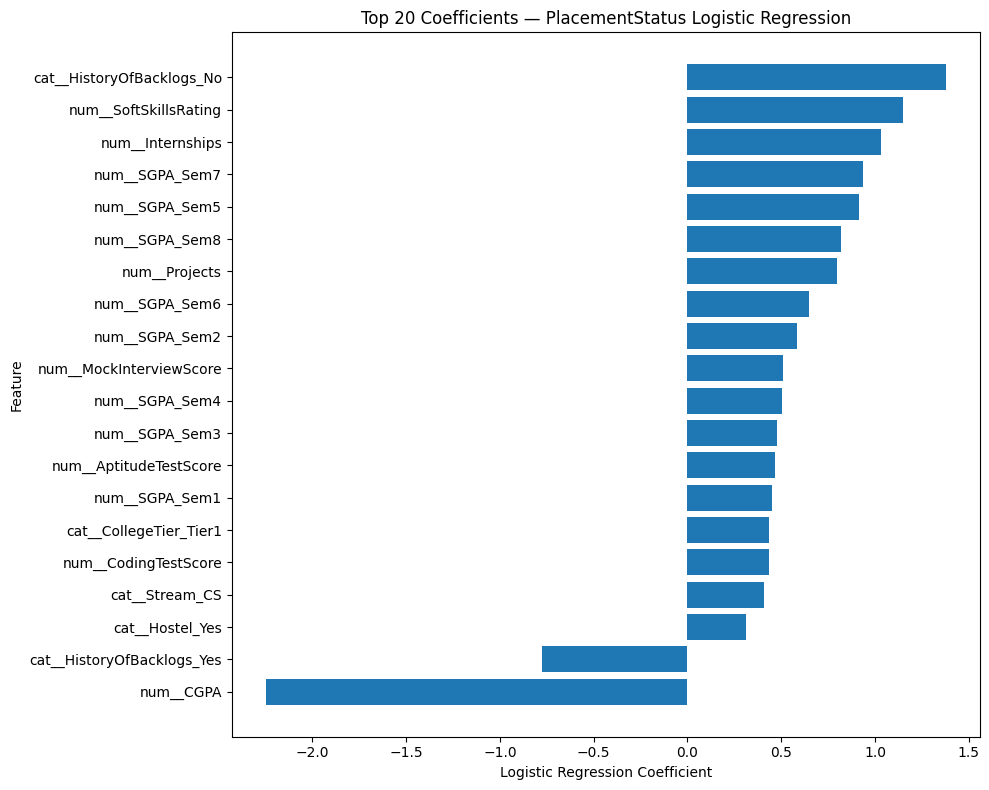

In [73]:
top20_binary = coef_binary_df.head(20).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_binary["Feature"],
    top20_binary["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Coefficients — PlacementStatus Logistic Regression")

plt.tight_layout()
plt.show()

In [74]:
feature_names_multi = (
    multi_lr
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

multi_coefficients = (
    multi_lr
    .named_steps["classifier"]
    .coef_
)

print("Coefficient matrix shape:")
print(multi_coefficients.shape)

Coefficient matrix shape:
(3, 49)


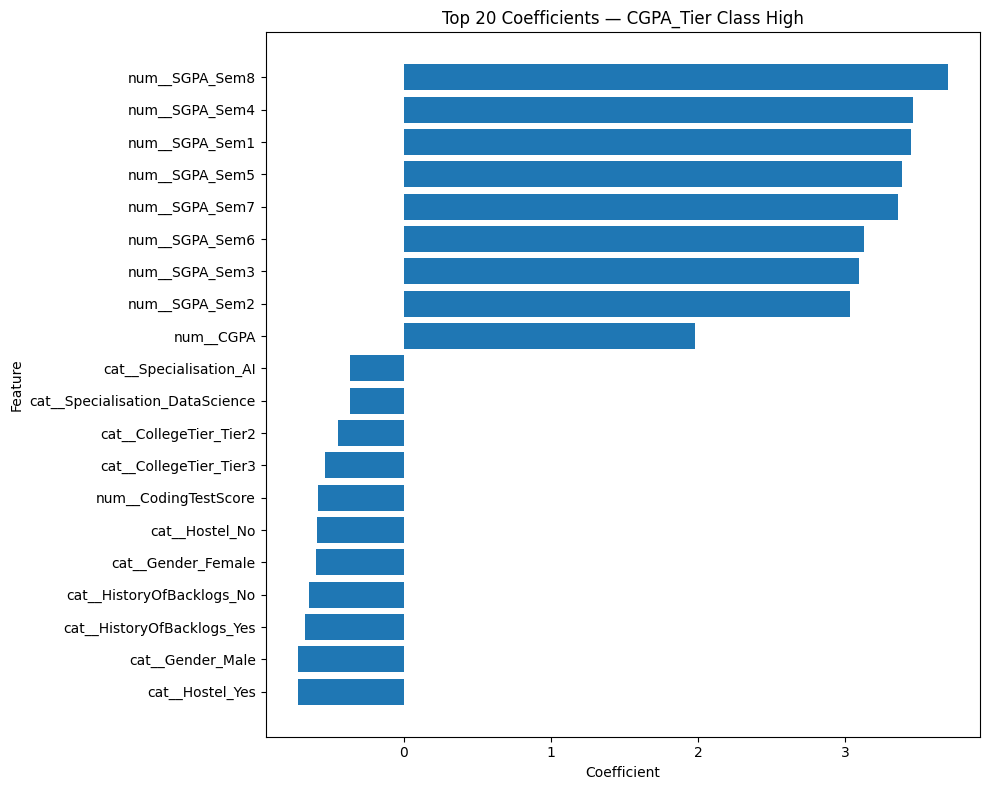

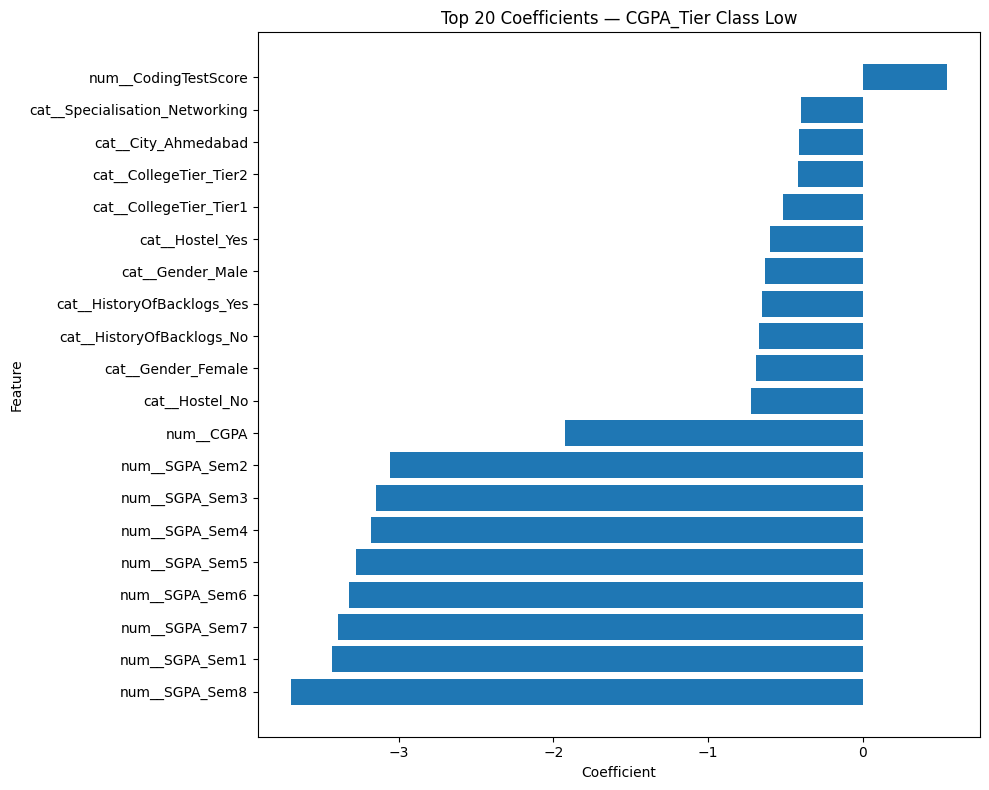

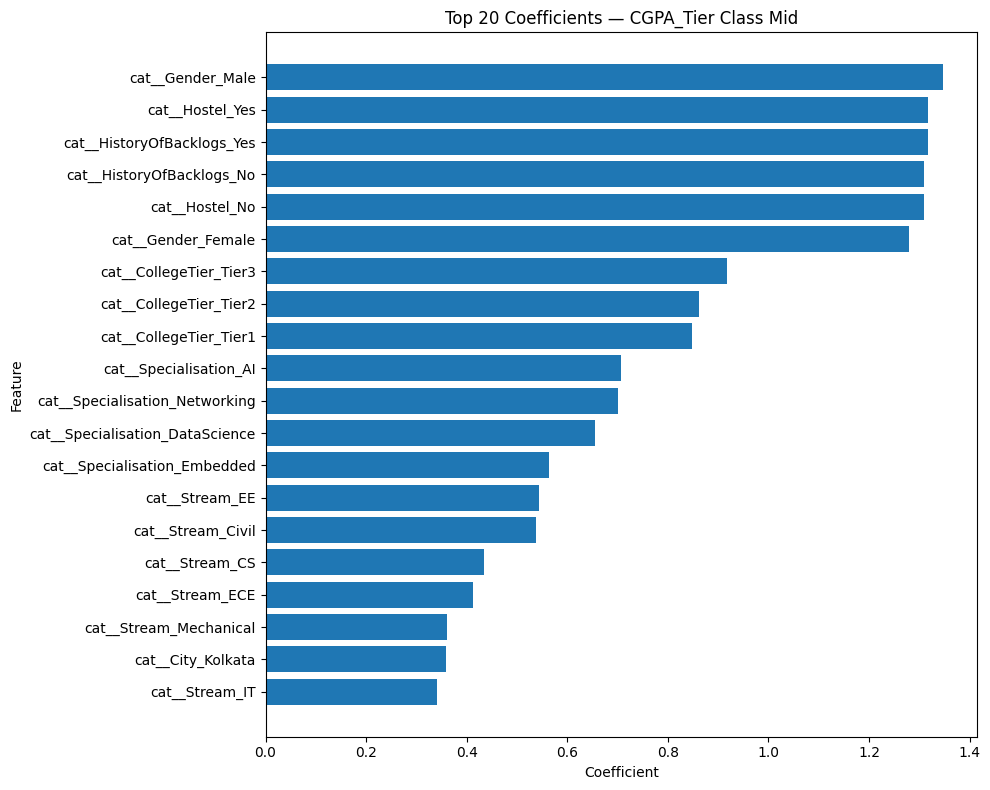

In [75]:
classes = multi_lr.named_steps["classifier"].classes_

for i, class_label in enumerate(classes):

    coef_df = pd.DataFrame({
        "Feature": feature_names_multi,
        "Coefficient": multi_coefficients[i]
    })

    coef_df["AbsoluteCoefficient"] = (
        coef_df["Coefficient"].abs()
    )

    coef_df = coef_df.sort_values(
        "AbsoluteCoefficient",
        ascending=False
    )

    top20 = coef_df.head(20).sort_values(
        "Coefficient"
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top20["Feature"],
        top20["Coefficient"]
    )

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(
        f"Top 20 Coefficients — CGPA_Tier Class {class_label}"
    )

    plt.tight_layout()
    plt.show()

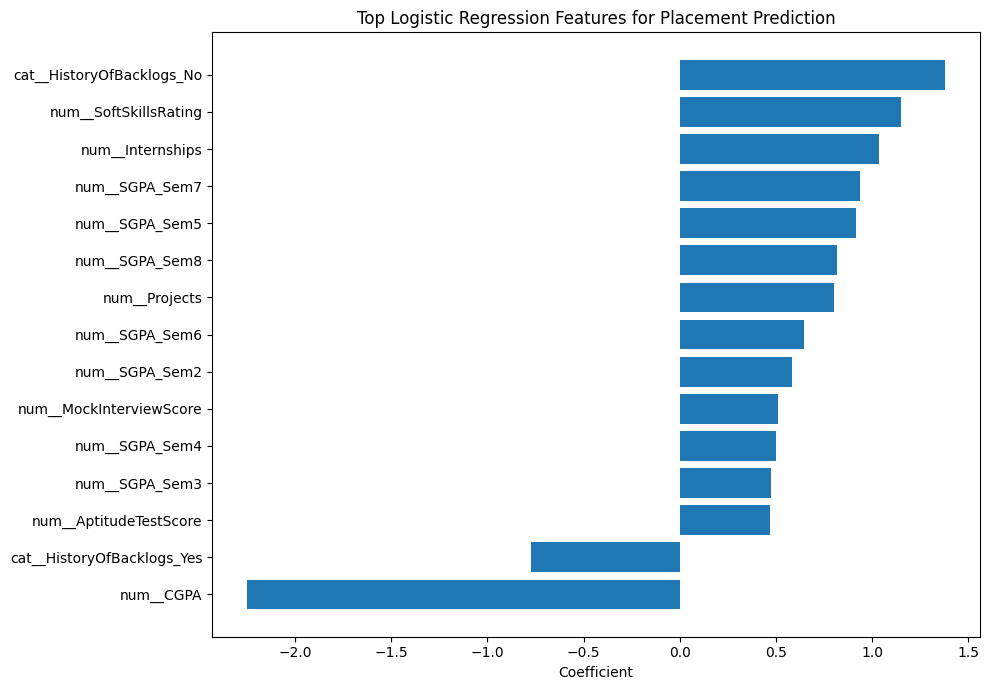

In [76]:
coef_plot = coef_binary_df.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title(
    "Top Logistic Regression Features for Placement Prediction"
)

plt.tight_layout()
plt.show()

In [77]:
print("\n\nMODEL 1: BINARY PLACEMENT STATUS")
binary_result = evaluate_classifier(
    binary_lr,
    X_train_bin,
    y_train_bin,
    X_val_bin,
    y_val_bin
)


print("\n\nMODEL 2: MULTINOMIAL CGPA TIER")
multi_result = evaluate_classifier(
    multi_lr,
    X_train_multi,
    y_train_multi,
    X_val_multi,
    y_val_multi
)


print("\n\nMODEL 3: ACADEMIC PLACEMENT STATUS")
academic_result = evaluate_classifier(
    academic_lr,
    X_train_acad,
    y_train_acad,
    X_val_acad,
    y_val_acad
)



MODEL 1: BINARY PLACEMENT STATUS
MODEL EVALUATION

Train Accuracy: 0.9247
Validation Accuracy: 0.9223

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3943
           1       0.93      0.96      0.94      7594

    accuracy                           0.92     11537
   macro avg       0.92      0.91      0.91     11537
weighted avg       0.92      0.92      0.92     11537


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[3387  556]
 [ 341 7253]]


MODEL 2: MULTINOMIAL CGPA TIER
MODEL EVALUATION

Train Accuracy: 0.9693
Validation Accuracy: 0.9667

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

        High       0.98      0.97      0.97      3851
